# 2. BC카드 매출 효과 분석 (주력)

**데이터**: BC카드 주간/월간 매출 (2025.01~2026.04)
**방법**: CausalImpact + DID + Staggered DID 교차검증
**핵심**: 방송 촬영 읍면동 vs 비촬영 읍면동의 외지인 매출 변화

### 외지인 소비 정의 (설계 결정)
- **주 지표**: `EXCL_RSDT` (거주자 제외) - 아산시 주소 보유자의 카드 소비를 제외
- **강건성 검증**: `EXCL_LC` (현지 제외) - 두 정의에서 결과 일치 시 "외지인 정의에 robust"
- **지역 키**: 반드시 `FRCS_DONG` (가맹점 위치) 사용. `CUST_DONG`(고객 거주지)으로 잡으면 분석이 틀어짐

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from config import (CARD_DIR, CARD_FILE_PATTERNS, BROADCAST_DONG_MAP,
                     BROADCAST_GROUPS, ALL_TREATED_DONGS, ALL_TOURISM_KEYWORDS,
                     read_csv_auto, load_monthly_data, classify_tourism)
from causal_utils import SimpleCausalImpact, run_did, staggered_did, plot_event_study, robustness_check

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 2.1 데이터 로드 & 읍면동 목록 파악

**주 지표**: `AS_WEEK_CCND_EXCL_RSDT_CRTR_CCND_CSPT_DONG` (거주자 제외, 주간, 동 단위)
**강건성**: `AS_WEEK_CCND_CUST_CRTR_CCND_EXCL_LC_CSPT_DONG` (현지 제외, 주간, 동 단위)

In [35]:
# 주 지표: 거주자 제외 외지인 매출
df_main = load_monthly_data(CARD_DIR, CARD_FILE_PATTERNS['main'])
print(f"[주 지표 EXCL_RSDT] 로드: {df_main.shape}")
print(f"컬럼: {list(df_main.columns)}")
df_main.head(3)

[주 지표 EXCL_RSDT] 로드: (541322, 41)
컬럼: ['CRTR_WEEK', 'CUST_CTPV_NM', 'CUST_SGG_NM', 'CUST_DONG_NM', 'CUST_DONG_CD', 'FRCS_CTPV_NM', 'FRCS_SGG_NM', 'FRCS_DONG_NM', 'FRCS_DONG_CD', 'TOBIZ_CD', 'TOBIZ_NM', 'FRCS_SLS_SZ', 'ALL_USE_NOCS', 'INDIV_USE_NOCS', 'CORP_USE_NOCS', 'ML_USE_NOCS', 'FM_USE_NOCS', 'TEEN_BELOW_USE_NOCS', 'TEEN_USE_NOCS', 'TWT_USE_NOCS', 'TRT_USE_NOCS', 'FRT_USE_NOCS', 'FFT_USE_NOCS', 'SXT_USE_NOCS', 'SVT_ABV_USE_NOCS', 'ALL_USE_AMT', 'INDIV_USE_AMT', 'CORP_USE_AMT', 'ML_USE_AMT', 'FM_USE_AMT', 'TEEN_BELOW_USE_AMT', 'TEEN_USE_AMT', 'TWT_USE_AMT', 'TRT_USE_AMT', 'FRT_USE_AMT', 'FFT_USE_AMT', 'SXT_USE_AMT', 'SVT_ABV_USE_AMT', 'FRCS_CNT', 'CRTR_YM', 'FRCS_CTPV_CD']


,CRTR_WEEK,CUST_CTPV_NM,CUST_SGG_NM,CUST_DONG_NM,CUST_DONG_CD,FRCS_CTPV_NM,FRCS_SGG_NM,FRCS_DONG_NM,FRCS_DONG_CD,TOBIZ_CD,...,TEEN_USE_AMT,TWT_USE_AMT,TRT_USE_AMT,FRT_USE_AMT,FFT_USE_AMT,SXT_USE_AMT,SVT_ABV_USE_AMT,FRCS_CNT,CRTR_YM,FRCS_CTPV_CD
0,202501,서울특별시,성동구,성수2가3동,11200690,충청남도,아산시,염치읍,44200250,3309,...,0,0,0,0,0,0,0,2.0,202501.0,NaN
1,202501,서울특별시,광진구,자양2동,11215830,충청남도,아산시,염치읍,44200250,4010,...,0,0,0,73390,0,0,0,1.0,202501.0,NaN
2,202501,서울특별시,광진구,자양2동,11215830,충청남도,아산시,염치읍,44200250,4020,...,0,0,0,17200,0,0,0,1.0,202501.0,NaN


In [36]:
# 강건성 검증: 현지 제외 매출
df_robust = load_monthly_data(CARD_DIR, CARD_FILE_PATTERNS['robust'])
print(f"[강건성 EXCL_LC] 로드: {df_robust.shape}")
print(f"컬럼: {list(df_robust.columns)}")

[강건성 EXCL_LC] 로드: (610228, 40)
컬럼: ['CRTR_WEEK', 'CUST_CTPV_NM', 'CUST_SGG_NM', 'CUST_DONG_NM', 'CUST_DONG_CD', 'FRCS_CTPV_NM', 'FRCS_SGG_NM', 'FRCS_DONG_NM', 'FRCS_DONG_CD', 'TOBIZ_CD', 'TOBIZ_NM', 'FRCS_SLS_SZ', 'ALL_USE_NOCS', 'INDIV_USE_NOCS', 'CORP_USE_NOCS', 'ML_USE_NOCS', 'FM_USE_NOCS', 'TEEN_BELOW_USE_NOCS', 'TEEN_USE_NOCS', 'TWT_USE_NOCS', 'TRT_USE_NOCS', 'FRT_USE_NOCS', 'FFT_USE_NOCS', 'SXT_USE_NOCS', 'SVT_ABV_USE_NOCS', 'ALL_USE_AMT', 'INDIV_USE_AMT', 'CORP_USE_AMT', 'ML_USE_AMT', 'FM_USE_AMT', 'TEEN_BELOW_USE_AMT', 'TEEN_USE_AMT', 'TWT_USE_AMT', 'TRT_USE_AMT', 'FRT_USE_AMT', 'FFT_USE_AMT', 'SXT_USE_AMT', 'SVT_ABV_USE_AMT', 'FRCS_CNT', 'CRTR_YM']


In [37]:
# ★ 가맹점 위치(FRCS_DONG) 컬럼 특정
# FRCS_DONG_NM이 있으면 그걸, 없으면 FRCS가 포함된 DONG 컬럼
frcs_dong_candidates = [c for c in df_main.columns if 'FRCS' in c and 'DONG' in c and 'NM' in c]
if frcs_dong_candidates:
    dong_col = frcs_dong_candidates[0]
else:
    frcs_dong_candidates = [c for c in df_main.columns if 'FRCS' in c and 'DONG' in c]
    dong_col = frcs_dong_candidates[0] if frcs_dong_candidates else None

print(f"가맹점 동 컬럼: {dong_col}")

# 전체 읍면동 목록
if dong_col:
    all_dongs = sorted(df_main[dong_col].dropna().unique())
    print(f"\n전체 읍면동 ({len(all_dongs)}개):")
    for d in all_dongs:
        marker = " [처치군]" if any(t in str(d) for t in ALL_TREATED_DONGS) else " [통제군]"
        print(f"  {d}{marker}")

    treated_dongs = [d for d in all_dongs if any(t in str(d) for t in ALL_TREATED_DONGS)]
    control_dongs = [d for d in all_dongs if not any(t in str(d) for t in ALL_TREATED_DONGS)]
    print(f"\n처치군 {len(treated_dongs)}개, 통제군 {len(control_dongs)}개")
    print(f"통제군 비율: {len(control_dongs)/len(all_dongs)*100:.0f}% (충분한지 확인)")
else:
    print("FRCS_DONG 컬럼을 찾지 못함. 컬럼 목록 확인 후 수동 지정 필요")

가맹점 동 컬럼: FRCS_DONG_NM

전체 읍면동 (17개):
  도고면 [통제군]
  둔포면 [통제군]
  배방읍 [통제군]
  선장면 [통제군]
  송악면 [처치군]
  신창면 [처치군]
  염치읍 [처치군]
  영인면 [처치군]
  온양1동 [통제군]
  온양2동 [통제군]
  온양3동 [통제군]
  온양4동 [통제군]
  온양5동 [통제군]
  온양6동 [통제군]
  음봉면 [통제군]
  인주면 [통제군]
  탕정면 [통제군]

처치군 4개, 통제군 13개
통제군 비율: 76% (충분한지 확인)


## 2.2 주간 매출 시계열 구축

**목표 패널 형태**: `가맹점읍면동 x 주(week)`

주차 정의: ISO week 기준 월요일 시작으로 통일

In [38]:
# 시간/매출/건수 컬럼 파악
time_cols = [c for c in df_main.columns if 'YM' in c or 'WEEK' in c.upper() or 'WK' in c.upper() or 'CRTR' in c]
amt_cols = [c for c in df_main.columns if 'AMT' in c.upper()]
cnt_cols = [c for c in df_main.columns if 'NOCS' in c.upper() or 'CNT' in c.upper()]

print(f"시간 컬럼: {time_cols}")
print(f"매출액 컬럼: {amt_cols}")
print(f"건수 컬럼: {cnt_cols}")

시간 컬럼: ['CRTR_WEEK', 'CRTR_YM']
매출액 컬럼: ['ALL_USE_AMT', 'INDIV_USE_AMT', 'CORP_USE_AMT', 'ML_USE_AMT', 'FM_USE_AMT', 'TEEN_BELOW_USE_AMT', 'TEEN_USE_AMT', 'TWT_USE_AMT', 'TRT_USE_AMT', 'FRT_USE_AMT', 'FFT_USE_AMT', 'SXT_USE_AMT', 'SVT_ABV_USE_AMT']
건수 컬럼: ['ALL_USE_NOCS', 'INDIV_USE_NOCS', 'CORP_USE_NOCS', 'ML_USE_NOCS', 'FM_USE_NOCS', 'TEEN_BELOW_USE_NOCS', 'TEEN_USE_NOCS', 'TWT_USE_NOCS', 'TRT_USE_NOCS', 'FRT_USE_NOCS', 'FFT_USE_NOCS', 'SXT_USE_NOCS', 'SVT_ABV_USE_NOCS', 'FRCS_CNT']


In [39]:
# 주요 매출 컬럼 선택
amt_col = 'ALL_USE_AMT' if 'ALL_USE_AMT' in df_main.columns else amt_cols[0]
print(f"주 매출 컬럼: {amt_col}")

# CRTR_YM, CRTR_WEEK가 float으로 읽힘 → 정수로 정리 (.0 제거)
df_main['YM'] = df_main['CRTR_YM'].astype('Int64').astype(str)

# CRTR_WEEK는 'YYYYWW' 형태의 완전한 주차 식별자 → 그대로 period로 사용
df_main['period'] = df_main['CRTR_WEEK'].astype('Int64').astype(str)
print("주차 정의: CRTR_WEEK (YYYYWW)")

# period 결측 제거 후 문자열 통일
mask_bad = df_main['period'].isin(['<NA>', 'nan']) | df_main['period'].isna()
if mask_bad.sum() > 0:
    print(f"⚠ period 결측 {int(mask_bad.sum())}건 → 제외")
    df_main = df_main[~mask_bad].copy()

# CRTR_WEEK 주차 규칙 자동 감지 (연중누적 vs 월내) 후 '주 시작일(월요일)' 날짜 생성
#  - YYYYWW를 그 해의 WW번째 ISO주 월요일로 해석 시도
#  - 실패하거나 비정상이면 월내주차로 간주하여 YM+주차 근사
import datetime as _dt

def _week_to_monday(week_code, ym_code):
    s = str(week_code)
    yy, ww = int(s[:4]), int(s[4:])
    # 1) 연중 누적 ISO주 해석
    if 1 <= ww <= 53:
        try:
            return _dt.date.fromisocalendar(yy, ww, 1)  # 월요일
        except ValueError:
            pass
    # 2) 월내 주차 해석: YM의 1일 + (ww-1)*7
    try:
        ym = str(ym_code)
        base = _dt.date(int(ym[:4]), int(ym[4:6]), 1)
        return base + _dt.timedelta(days=(max(ww, 1) - 1) * 7)
    except Exception:
        return None

df_main['week_start'] = [
    _week_to_monday(w, y) for w, y in zip(df_main['CRTR_WEEK'].astype('Int64'),
                                          df_main['CRTR_YM'].astype('Int64'))
]
df_main['week_start'] = pd.to_datetime(df_main['week_start'], errors='coerce')
n_bad_date = df_main['week_start'].isna().sum()
if n_bad_date > 0:
    print(f"⚠ 주 시작일 변환 실패 {int(n_bad_date)}건 → 제외")
    df_main = df_main[df_main['week_start'].notna()].copy()

# 이후 모든 시점 매칭의 단일 기준 = week_start (실제 날짜)
print(f"\nperiod 샘플: {sorted(df_main['period'].unique())[:10]}")
print(f"주 시작일 범위: {df_main['week_start'].min().date()} ~ {df_main['week_start'].max().date()}")
print(f"총 기간 수: {df_main['period'].nunique()}")


주 매출 컬럼: ALL_USE_AMT
주차 정의: CRTR_WEEK (YYYYWW)

period 샘플: ['202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510']
주 시작일 범위: 2024-12-30 ~ 2026-04-13
총 기간 수: 68


In [40]:
# 처치/통제 라벨링
df_main['group'] = df_main[dong_col].apply(
    lambda x: 'treated' if any(t in str(x) for t in ALL_TREATED_DONGS) else 'control'
)

# 읍면동 그룹별 주간 매출 합계 (week_start 기준 정렬 → 시간 순서 보장)
ws_order = df_main[['period', 'week_start']].drop_duplicates().sort_values('week_start')
period_seq = ws_order['period'].tolist()  # 시간순 period 목록

weekly_ts = df_main.groupby(['period', 'group'])[amt_col].sum().unstack('group').fillna(0)
weekly_ts = weekly_ts.reindex(period_seq)  # 날짜순 재정렬
print(f"시계열 shape: {weekly_ts.shape}")
weekly_ts.head(10)


시계열 shape: (68, 2)


group,control,treated
period,,
202501,978985721,203167284
202502,902744436,280769116
202503,1014675378,245752311
202504,388693500,80236005
202505,883556625,219030238
202506,903450918,257685429
202507,764088641,267043091
202508,740297457,279120399
202509,869596336,275674946


## 2.3 시계열 시각화: 처치군 vs 통제군

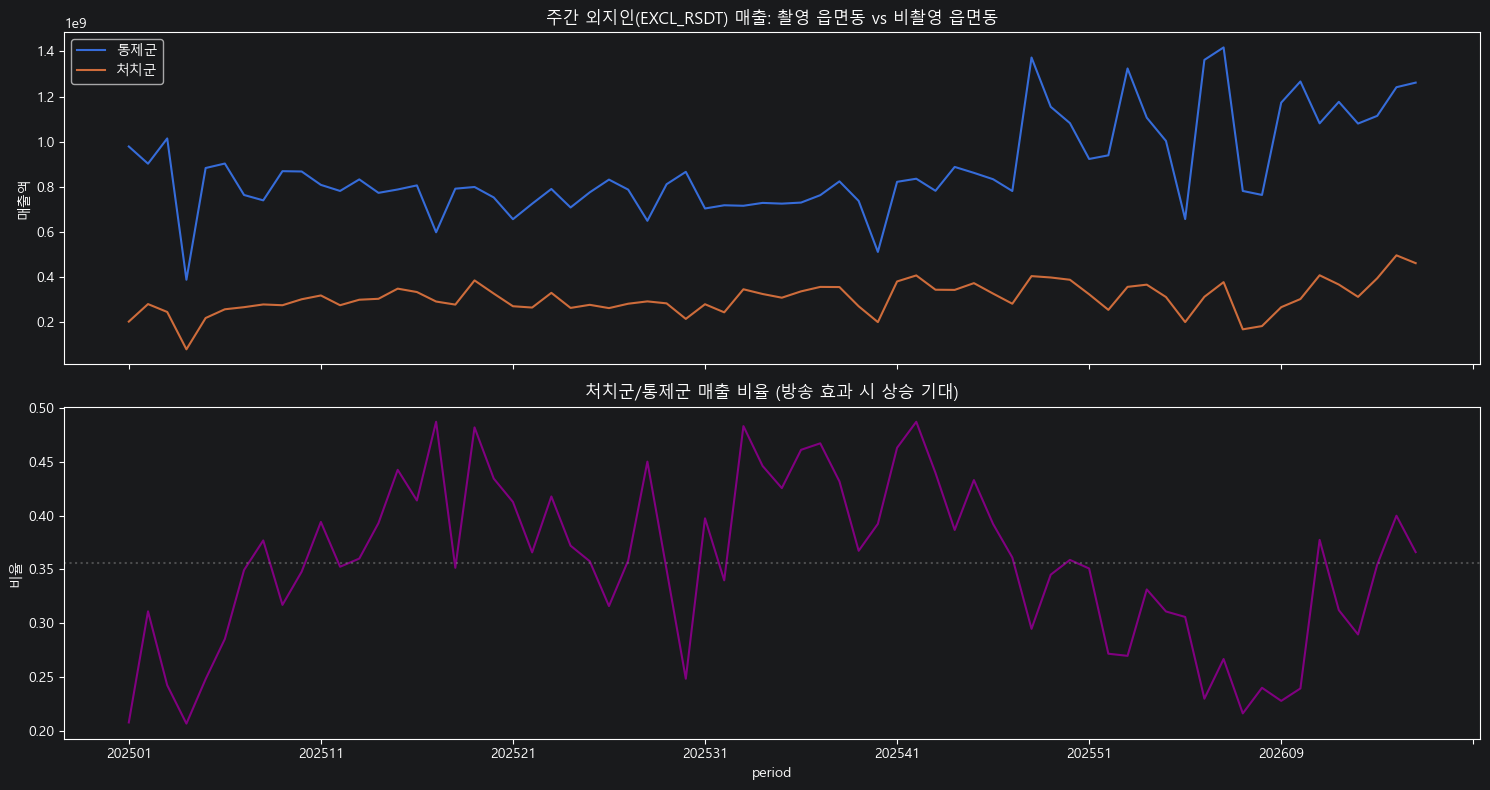

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# 절대값
ax1 = axes[0]
weekly_ts.plot(ax=ax1)
ax1.set_title('주간 외지인(EXCL_RSDT) 매출: 촬영 읍면동 vs 비촬영 읍면동')
ax1.set_ylabel('매출액')
ax1.legend(['통제군', '처치군'])

# 방송 시점 표시
broadcast_dates = {
    '전국노래자랑': '2025-06',
    '11월캠페인': '2025-11',
    '뛰어야산다2': '2026-01',
    '황제파워': '2026-05',
}
for name, ym in broadcast_dates.items():
    matches = [p for p in weekly_ts.index if ym in str(p)]
    if matches:
        idx = weekly_ts.index.get_loc(matches[0])
        for ax in axes:
            ax.axvline(idx, color='red', linestyle='--', alpha=0.7)
            ax.text(idx, ax.get_ylim()[1]*0.95, name, fontsize=8, rotation=90, va='top', color='red')

# 비율 (처치군/통제군)
ax2 = axes[1]
ratio = weekly_ts['treated'] / weekly_ts['control'].replace(0, np.nan)
ratio.plot(ax=ax2, color='purple')
ax2.axhline(ratio.mean(), color='gray', linestyle=':', alpha=0.5)
ax2.set_title('처치군/통제군 매출 비율 (방송 효과 시 상승 기대)')
ax2.set_ylabel('비율')

plt.tight_layout()
plt.show()

## 2.4 업종별 분해 (관광 vs 일반)

- **관광 업종** (숙박/음식/관광레저): 방송 효과의 직접 대상
- **일반 업종**: 방송과 무관해야 함 → 플라시보 역할

In [42]:
# 업종 컬럼 확인
biz_col = [c for c in df_main.columns if 'TOBIZ' in c and 'NM' in c]
if biz_col:
    biz_col = biz_col[0]
    df_main['tourism_category'] = df_main[biz_col].apply(classify_tourism)
    
    print(f"업종 분류 결과:")
    print(df_main['tourism_category'].value_counts())
    
    print(f"\n상위 20개 업종 (매출 기준):")
    display(df_main.groupby(biz_col)[amt_col].sum().sort_values(ascending=False).head(20))
else:
    biz_col = None
    print("업종 컬럼 없음 - 주간 EXCL_RSDT 파일에는 업종이 없을 수 있음")
    print("→ 월간 상세 파일(AS_MM_CCND_CUST_CRTR_CCND_CSPT_DONG)에서 업종별 분석 필요")

업종 분류 결과:
tourism_category
기타      382625
음식      115316
교통       33301
숙박        9374
관광레저       592
쇼핑         114
Name: count, dtype: int64

상위 20개 업종 (매출 기준):


TOBIZ_NM
주유소        22268243690
일반한식       10875851060
편의점        10618821202
슈퍼마켓        5974613394
공공요금        3289521184
골프경기장       3184990530
기타숙박업       2384296359
서양음식        2285882670
기타업종        1950243001
대형할인점       1676834020
정장          1362908104
농축협직영매장     1015342030
특급호텔         894238340
스포츠의류        725861230
중국음식         721537242
위탁급식업        681454958
기타음료식품       663890928
의원           659383458
스포츠레져용품      637152809
정육점          556550076
Name: ALL_USE_AMT, dtype: int64

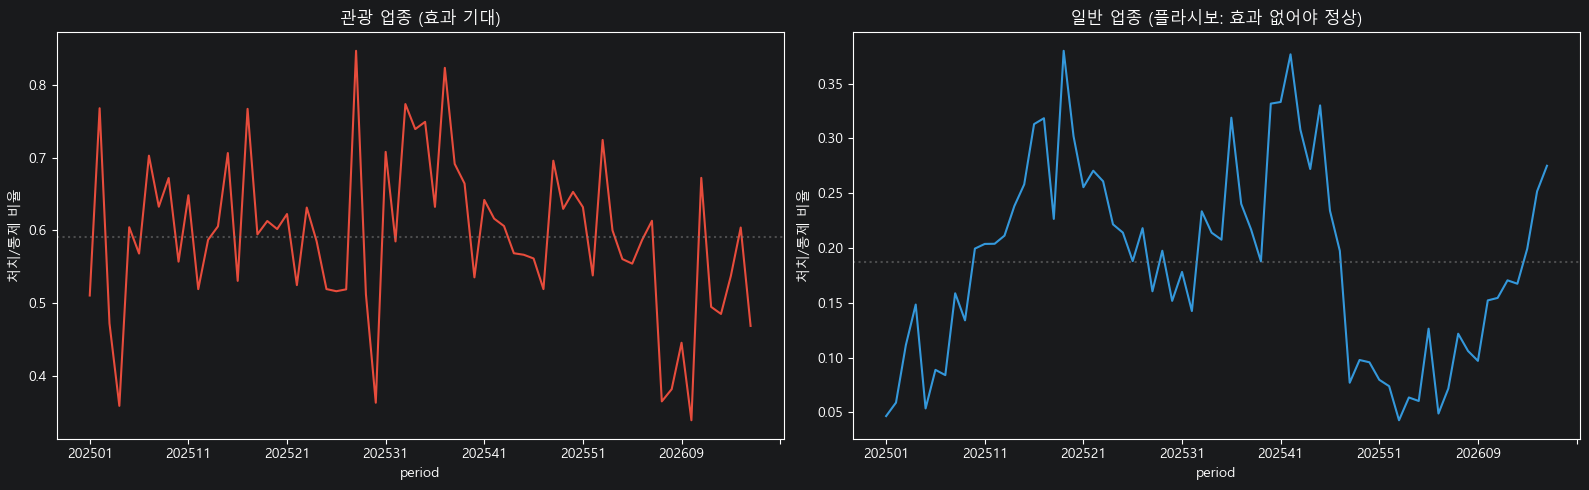

In [43]:
if biz_col:
    df_main['is_tourism'] = df_main['tourism_category'] != '기타'
    
    # 관광업종 vs 일반업종 시계열
    tourism_ts = df_main[df_main['is_tourism']].groupby(['period', 'group'])[amt_col].sum().unstack('group').fillna(0)
    general_ts = df_main[~df_main['is_tourism']].groupby(['period', 'group'])[amt_col].sum().unstack('group').fillna(0)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for ax, ts, title, color in [
        (axes[0], tourism_ts, '관광 업종 (효과 기대)', '#e74c3c'),
        (axes[1], general_ts, '일반 업종 (플라시보: 효과 없어야 정상)', '#3498db'),
    ]:
        if 'treated' in ts.columns and 'control' in ts.columns:
            r = ts['treated'] / ts['control'].replace(0, np.nan)
            r.plot(ax=ax, color=color)
            ax.axhline(r.mean(), color='gray', linestyle=':', alpha=0.5)
            ax.set_title(title)
            ax.set_ylabel('처치/통제 비율')
    
    plt.tight_layout()
    plt.show()

## 2.5 CausalImpact 분석 (고립 방송용)

ruptures 의존성 문제 회피를 위해 `causal_utils.SimpleCausalImpact` 사용
(순수 statsmodels UnobservedComponents 기반)

In [44]:
# period → 정수 인덱스 매핑 (CausalImpact용). 시간순(period_seq) 기준.
periods_sorted = [p for p in period_seq if p in set(weekly_ts.index)]
print(f"period 샘플: {periods_sorted[:5]} ... {periods_sorted[-5:]}")
print(f"총 {len(periods_sorted)}개 기간")

period_to_idx = {p: i for i, p in enumerate(periods_sorted)}

# period → week_start(날짜) 룩업
_p2date = (df_main[['period', 'week_start']].drop_duplicates()
           .set_index('period')['week_start'])

def find_period_idx(ym_prefix):
    """YYYYMM(연월) 입력 → 그 '달'에 속하는 주(week_start 기준)들의 인덱스 범위 반환.
    period가 주차코드(YYYYWW)라도 week_start의 실제 달로 매칭하므로 안전."""
    ym = ym_prefix.replace('-', '')
    yy, mm = int(ym[:4]), int(ym[4:6])
    matches = [i for p, i in period_to_idx.items()
               if (pd.notna(_p2date.get(p))
                   and _p2date.get(p).year == yy
                   and _p2date.get(p).month == mm)]
    return (min(matches), max(matches)) if matches else (None, None)


period 샘플: ['202501', '202502', '202503', '202504', '202505'] ... ['202612', '202613', '202614', '202615', '202616']
총 68개 기간


그룹A 전국노래자랑: pre=[1:21], post=[22:30]
CausalImpact 분석 결과
실제 합계:          2,488,731,148
예측 합계(반사실):   2,685,076,341
절대 효과:           -196,345,193
상대 효과:                   -7.3%
p-value:                   0.4645
유의성 (α=0.05): 유의하지 않음


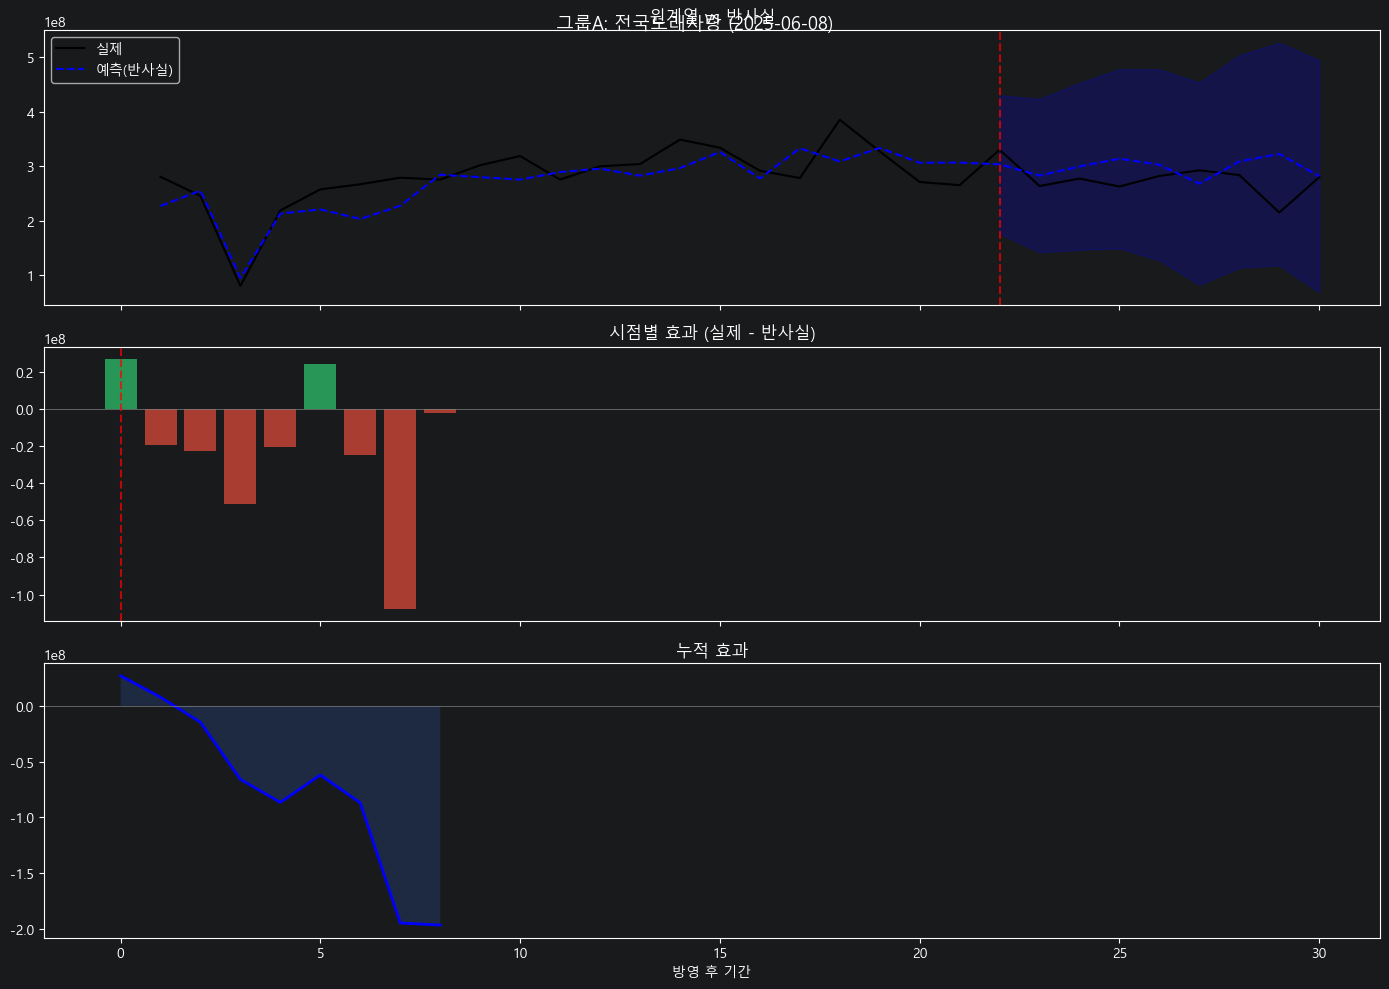

In [45]:
# === 분석 그룹 A: 전국노래자랑 (2025-06-08) ===
# pre: 2025-01 ~ 2025-05 / post: 2025-06 ~ 2025-07

pre_start_A, _ = find_period_idx('202501')
_, pre_end_A = find_period_idx('202505')
post_start_A, _ = find_period_idx('202506')
_, post_end_A = find_period_idx('202507')

print(f"그룹A 전국노래자랑: pre=[{pre_start_A}:{pre_end_A}], post=[{post_start_A}:{post_end_A}]")

if all(v is not None for v in [pre_start_A, pre_end_A, post_start_A, post_end_A]):
    # CausalImpact 실행
    ci_data_A = pd.DataFrame({
        'y': weekly_ts['treated'].values,
        'x1': weekly_ts['control'].values,
    })
    
    ci_A = SimpleCausalImpact(
        ci_data_A,
        pre_period=[pre_start_A, pre_end_A],
        post_period=[post_start_A, post_end_A],
    )
    print(ci_A.summary())
    ci_A.plot()
    plt.suptitle('그룹A: 전국노래자랑 (2025-06-08)', fontsize=13)
    plt.show()
else:
    print("기간 매핑 실패 - period 형식 확인 필요")

그룹B 11월캠페인: pre=[27:43], post=[44:52]
CausalImpact 분석 결과
실제 합계:          3,111,073,159
예측 합계(반사실):   3,760,620,871
절대 효과:           -649,547,712
상대 효과:                  -17.3%
p-value:                   0.0087
유의성 (α=0.05): 유의함


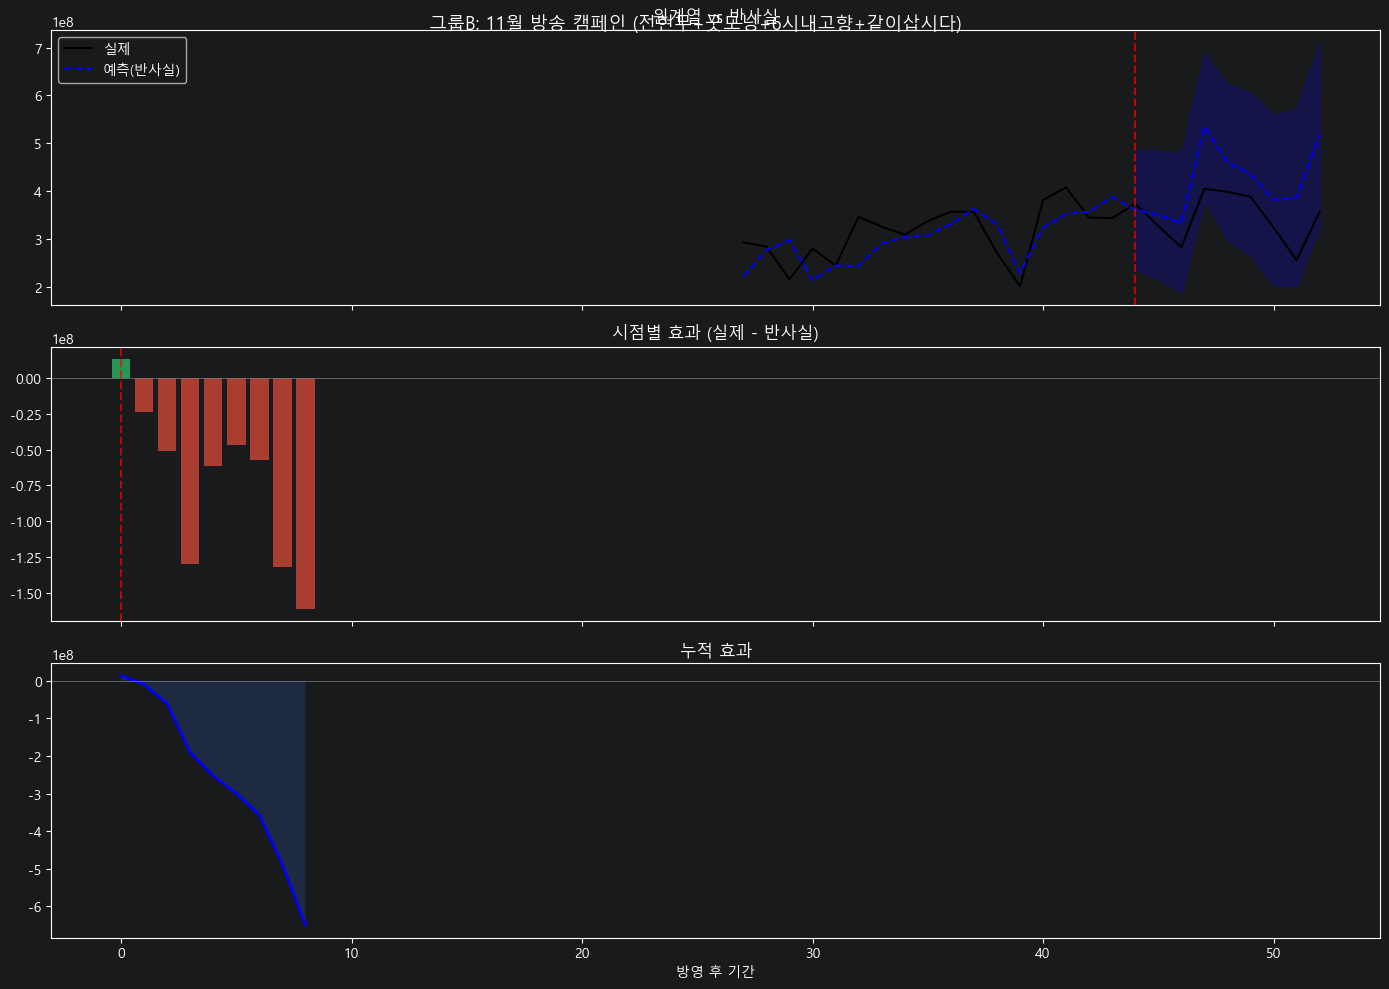

In [46]:
# === 분석 그룹 B: 11월 캠페인 (묶음) ===
# pre: 2025-07 ~ 2025-10 (전국노래자랑 효과 소멸 후)
# post: 2025-11 ~ 2025-12

pre_start_B, _ = find_period_idx('202507')
_, pre_end_B = find_period_idx('202510')
post_start_B, _ = find_period_idx('202511')
_, post_end_B = find_period_idx('202512')

print(f"그룹B 11월캠페인: pre=[{pre_start_B}:{pre_end_B}], post=[{post_start_B}:{post_end_B}]")

if all(v is not None for v in [pre_start_B, pre_end_B, post_start_B, post_end_B]):
    ci_data_B = pd.DataFrame({
        'y': weekly_ts['treated'].values,
        'x1': weekly_ts['control'].values,
    })
    
    ci_B = SimpleCausalImpact(
        ci_data_B,
        pre_period=[pre_start_B, pre_end_B],
        post_period=[post_start_B, post_end_B],
    )
    print(ci_B.summary())
    ci_B.plot()
    plt.suptitle('그룹B: 11월 방송 캠페인 (전현무+굿모닝+6시내고향+같이삽시다)', fontsize=13)
    plt.show()

그룹C 뛰어야산다2: pre=[40:52], post=[53:60]
CausalImpact 분석 결과
실제 합계:          2,189,835,042
예측 합계(반사실):   2,511,106,787
절대 효과:           -321,271,745
상대 효과:                  -12.8%
p-value:                   0.0472
유의성 (α=0.05): 유의함


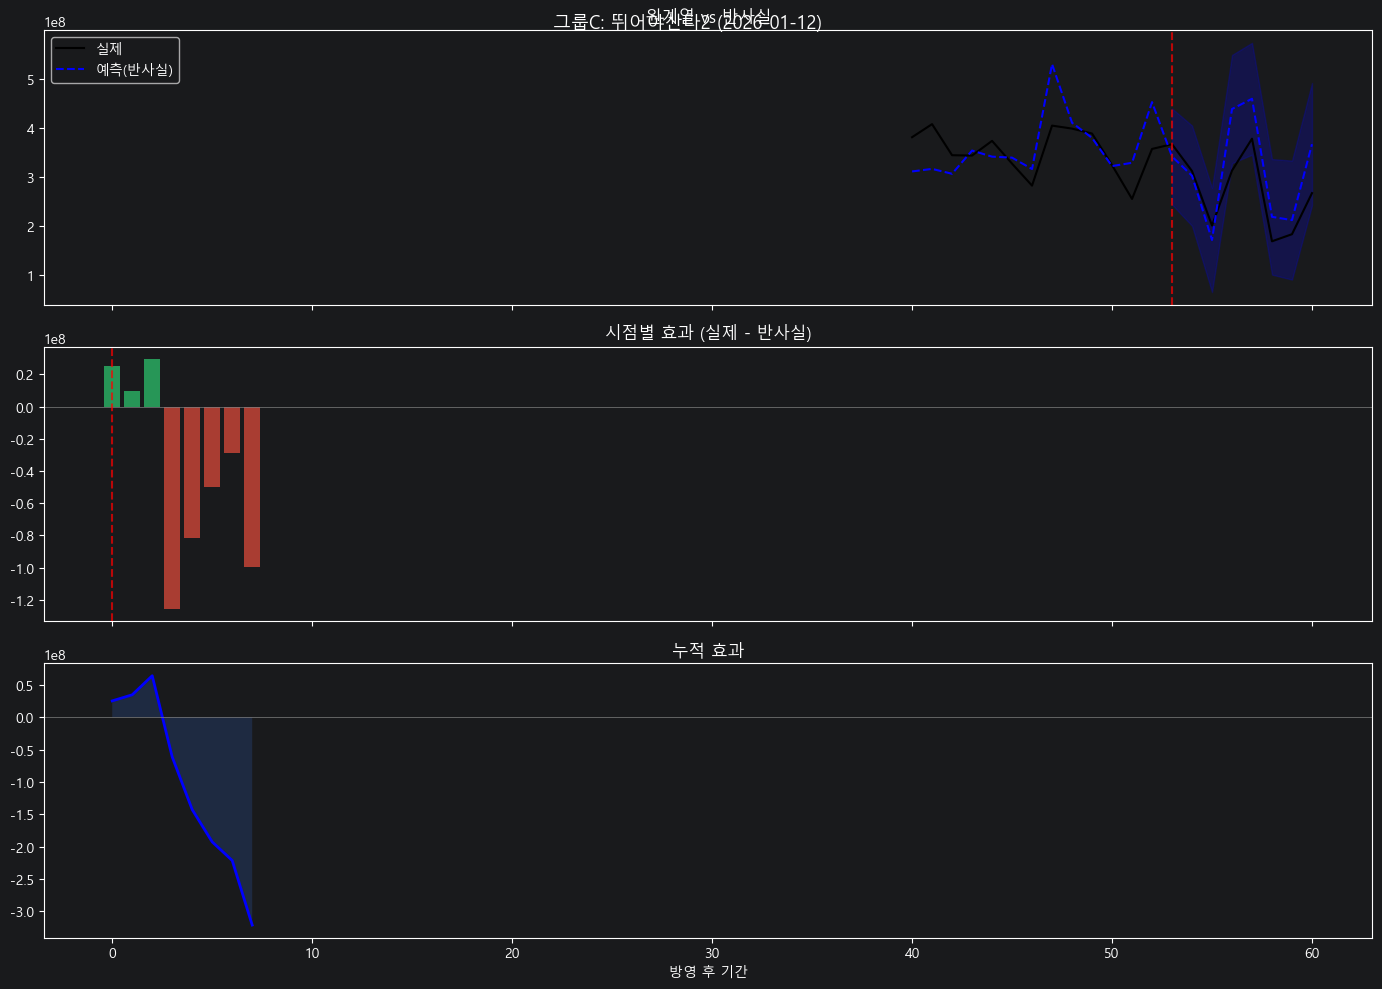

In [47]:
# === 분석 그룹 C: 뛰어야산다2 (2026-01-12) ===
# pre: 2025-10 ~ 2025-12 (주의: 11월 캠페인 잔류 가능)
# post: 2026-01 ~ 2026-02
# → 같이삽시다(12/15) → 뛰어야산다(1/12) 28일 간격, DID 교차검증 필수

pre_start_C, _ = find_period_idx('202510')
_, pre_end_C = find_period_idx('202512')
post_start_C, _ = find_period_idx('202601')
_, post_end_C = find_period_idx('202602')

print(f"그룹C 뛰어야산다2: pre=[{pre_start_C}:{pre_end_C}], post=[{post_start_C}:{post_end_C}]")

if all(v is not None for v in [pre_start_C, pre_end_C, post_start_C, post_end_C]):
    ci_data_C = pd.DataFrame({
        'y': weekly_ts['treated'].values,
        'x1': weekly_ts['control'].values,
    })
    
    ci_C = SimpleCausalImpact(
        ci_data_C,
        pre_period=[pre_start_C, pre_end_C],
        post_period=[post_start_C, post_end_C],
    )
    print(ci_C.summary())
    ci_C.plot()
    plt.suptitle('그룹C: 뛰어야산다2 (2026-01-12)', fontsize=13)
    plt.show()

## 2.6 DID (이중차분) 교차검증

In [48]:
# 패널 데이터 구축 (읍면동 x 기간)
panel = df_main.groupby([dong_col, 'period'])[amt_col].sum().reset_index()
panel['treated'] = panel[dong_col].apply(
    lambda x: 1 if any(t in str(x) for t in ALL_TREATED_DONGS) else 0
)

print(f"패널: {panel.shape}")
print(f"읍면동 {panel[dong_col].nunique()}개 x 기간 {panel['period'].nunique()}개")

패널: (1156, 4)
읍면동 17개 x 기간 68개


In [49]:
# DID: 그룹A 전국노래자랑
pre_periods_A = [p for p in panel['period'].unique() 
                  if str(p).replace('-','')[:6] >= '202501' and str(p).replace('-','')[:6] <= '202505']
post_periods_A = [p for p in panel['period'].unique() 
                   if str(p).replace('-','')[:6] >= '202506' and str(p).replace('-','')[:6] <= '202507']

if pre_periods_A and post_periods_A:
    panel_A = panel[panel['period'].isin(pre_periods_A + post_periods_A)].copy()
    panel_A['post'] = panel_A['period'].isin(post_periods_A).astype(int)
    
    result_A = run_did(panel_A, amt_col, 'treated', 'post', cluster_col=dong_col)
    print(f"\nDID 추정치: {result_A['did_coef']:,.0f}")
    print(f"p-value: {result_A['did_pvalue']:.4f}")
    print(result_A['summary_table'])


DID 추정치: 14,140,344
p-value: 0.1360
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     6.413e+07   2.26e+07      2.835      0.005    1.98e+07    1.08e+08
treated      -1.269e+07   2.92e+07     -0.434      0.664      -7e+07    4.46e+07
post          2972.8846   4.89e+06      0.001      1.000   -9.59e+06    9.59e+06
treated_post  1.414e+07   9.48e+06      1.491      0.136   -4.45e+06    3.27e+07


In [50]:
# DID: 그룹B 11월 캠페인
pre_periods_B = [p for p in panel['period'].unique() 
                  if str(p).replace('-','')[:6] >= '202507' and str(p).replace('-','')[:6] <= '202510']
post_periods_B = [p for p in panel['period'].unique() 
                   if str(p).replace('-','')[:6] >= '202511' and str(p).replace('-','')[:6] <= '202512']

if pre_periods_B and post_periods_B:
    panel_B = panel[panel['period'].isin(pre_periods_B + post_periods_B)].copy()
    panel_B['post'] = panel_B['period'].isin(post_periods_B).astype(int)
    
    result_B = run_did(panel_B, amt_col, 'treated', 'post', cluster_col=dong_col)
    print(f"\nDID 추정치: {result_B['did_coef']:,.0f}")
    print(f"p-value: {result_B['did_pvalue']:.4f}")
    print(result_B['summary_table'])


DID 추정치: 5,240,576
p-value: 0.4771
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     6.235e+07   2.18e+07      2.866      0.004    1.97e+07    1.05e+08
treated       7.897e+06   3.56e+07      0.222      0.824   -6.18e+07    7.76e+07
post         -1.162e+06   4.62e+06     -0.251      0.802   -1.02e+07     7.9e+06
treated_post  5.241e+06   7.37e+06      0.711      0.477   -9.21e+06    1.97e+07


## 2.7 Staggered DID (Callaway-Sant'Anna)

11월에 4개 방송이 몰려있으므로, "노출 시점이 다른 그룹"으로 자동 처리.
일반 TWFE DID는 시차 처치 시 추정량 오염 → CS 추정량 사용.

In [51]:
# Staggered DID용 패널 구축
# treatment_time = 해당 읍면동이 처음 방송에 노출된 시점 (실제 방영일 기준)

# 방송별 방영일(첫 노출일). 날짜로 보관하여 주차/연월 혼동 방지.
broadcast_air_dates = {
    '전국노래자랑 아산시편': '2025-06-08',
    '굿모닝 대한민국': '2025-11-12',
    '6시 내고향': '2025-11-13',
    '전현무계획2': '2025-11-07',
    '박원숙의 같이삽시다 시즌3': '2025-11-24',
    '뛰어야산다2': '2026-01-12',
    '황제성의 황제파워': '2026-05-09',
}
broadcast_air_dates = {k: pd.Timestamp(v) for k, v in broadcast_air_dates.items()}

# 각 읍면동의 첫 노출일 계산
dong_first_exposure = {}
for broadcast, dongs in BROADCAST_DONG_MAP.items():
    if dongs is None:
        continue
    air_date = broadcast_air_dates.get(broadcast)
    if air_date is None:
        continue
    for d in dongs:
        if d not in dong_first_exposure or air_date < dong_first_exposure[d]:
            dong_first_exposure[d] = air_date

print("읍면동별 첫 노출일:")
for d, dt in sorted(dong_first_exposure.items(), key=lambda x: x[1]):
    print(f"  {d}: {dt.date()}")

# 매칭 진단: 처치동 키가 실제 카드데이터 동 이름에 잡히는지
print("\n[매칭 테스트]")
_data_dongs = sorted(panel[dong_col].dropna().unique())
for key in dong_first_exposure:
    hits = [d for d in _data_dongs if key in str(d)]
    print(f"  '{key}' → {len(hits)}건: {hits[:5]}")


읍면동별 첫 노출일:
  온천동: 2025-06-08
  염치읍: 2025-11-12
  신창면: 2025-11-12
  영인면: 2025-11-24
  송악면: 2025-11-24

[매칭 테스트]
  '온천동' → 0건: []
  '염치읍' → 1건: ['염치읍']
  '신창면' → 1건: ['신창면']
  '영인면' → 1건: ['영인면']
  '송악면' → 1건: ['송악면']


In [52]:
# period를 시간 인덱스로 변환 (week_start 날짜순)
_period_date = (panel.merge(
    df_main[['period', 'week_start']].drop_duplicates(), on='period', how='left'
))
# panel에 week_start 부착
panel = panel.merge(df_main[['period', 'week_start']].drop_duplicates(),
                    on='period', how='left')

ordered_periods = (panel[['period', 'week_start']].drop_duplicates()
                   .sort_values('week_start')['period'].tolist())
period_order = {p: i for i, p in enumerate(ordered_periods)}
panel['time_idx'] = panel['period'].map(period_order)

# period별 week_start 룩업 (시점→인덱스 변환용)
_pdate = (panel[['period', 'week_start', 'time_idx']].drop_duplicates()
          .sort_values('week_start').reset_index(drop=True))

def date_to_time_idx(air_date):
    """방영일 이후(>=) 첫 주의 time_idx 반환. 없으면 NaN."""
    after = _pdate[_pdate['week_start'] >= air_date]
    if len(after) > 0:
        return int(after.iloc[0]['time_idx'])
    return np.nan

# 각 읍면동의 처치 시점 (정수 time_idx)
def get_treatment_time(dong_name):
    best = None
    for treated_dong, air_date in dong_first_exposure.items():
        if treated_dong in str(dong_name):
            ti = date_to_time_idx(air_date)
            if pd.notna(ti) and (best is None or ti < best):
                best = ti
    return best if best is not None else np.nan

panel['treatment_time'] = panel[dong_col].apply(get_treatment_time)

print("처치 시점 분포 (time_idx별 처치 읍면동 수):")
dist = panel.dropna(subset=['treatment_time']).groupby('treatment_time')[dong_col].nunique()
print(dist if len(dist) else "  (없음 — 매칭 실패)")
print(f"\n처치군 읍면동: {panel.loc[panel['treatment_time'].notna(), dong_col].nunique()}개")
print(f"통제군 읍면동: {panel.loc[panel['treatment_time'].isna(), dong_col].nunique()}개")


처치 시점 분포 (time_idx별 처치 읍면동 수):
treatment_time
46.0    2
47.0    2
Name: FRCS_DONG_NM, dtype: int64

처치군 읍면동: 4개
통제군 읍면동: 13개


ATT 추정 결과: 136개 (cohort x time)


,cohort,time,event_time,att,n_treated,n_control
0,46.0,0,-46.0,-2.610321e+07,2,15
1,46.0,1,-45.0,7.898816e+06,2,15
2,46.0,2,-44.0,-1.483805e+07,2,15
3,46.0,3,-43.0,2.363636e+06,2,15
4,46.0,4,-42.0,-1.294870e+07,2,15
5,46.0,5,-41.0,5.616886e+05,2,15
6,46.0,6,-40.0,7.915433e+06,2,15
7,46.0,7,-39.0,-4.358269e+06,2,15
8,46.0,8,-38.0,-7.250781e+05,2,15
9,46.0,9,-37.0,3.407950e+06,2,15


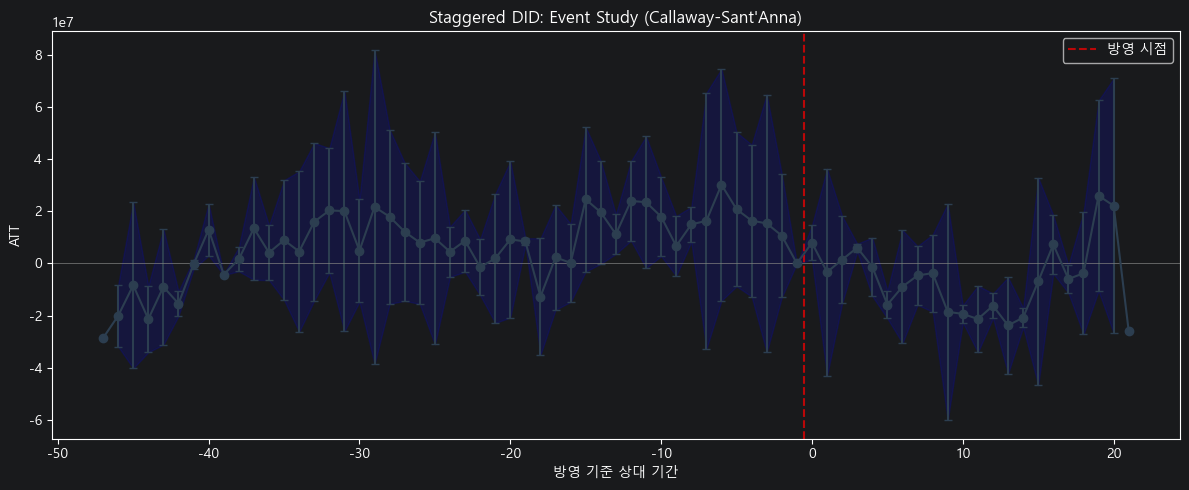


전체 ATT (event_time >= 0): -5,406,252


In [53]:
# Staggered DID 실행
att_results = staggered_did(
    panel, 
    y_col=amt_col,
    unit_col=dong_col,
    time_col='time_idx',
    treatment_time_col='treatment_time'
)

if len(att_results) > 0:
    print(f"ATT 추정 결과: {len(att_results)}개 (cohort x time)")
    display(att_results.head(20))
    
    # Event Study 플롯
    fig = plot_event_study(att_results, 'Staggered DID: Event Study (Callaway-Sant\'Anna)')
    plt.show()
    
    # 전체 ATT
    overall_att = att_results[att_results['event_time'] >= 0]['att'].mean()
    print(f"\n전체 ATT (event_time >= 0): {overall_att:,.0f}")
else:
    print("ATT 추정 실패 - 패널 구조 확인 필요")

## 2.8 플라시보 테스트

1. **가짜 시점 CausalImpact**: 방송 없던 2025-03에 가짜 개입 → 효과 0 기대
2. **일반 업종 DID**: 관광 무관 업종에서도 같은 효과? → No 기대
3. **Pre-trend 검정**: DID 평행추세 가정 확인

In [54]:
# 플라시보 1: 가짜 시점 (2025-03)
pre_start_P, _ = find_period_idx('202501')
_, pre_end_P = find_period_idx('202502')
post_start_P, _ = find_period_idx('202503')
_, post_end_P = find_period_idx('202504')

if all(v is not None for v in [pre_start_P, pre_end_P, post_start_P, post_end_P]):
    ci_data_P = pd.DataFrame({
        'y': weekly_ts['treated'].values,
        'x1': weekly_ts['control'].values,
    })
    ci_placebo = SimpleCausalImpact(
        ci_data_P,
        pre_period=[pre_start_P, pre_end_P],
        post_period=[post_start_P, post_end_P],
    )
    print("=== 플라시보 (2025-03 가짜 개입) ===")
    print(ci_placebo.summary())
    print(f"\n기대: 유의하지 않음 → {'PASS' if not ci_placebo.summary_stats['significant'] else 'FAIL (설계 문제 신호)'}")

=== 플라시보 (2025-03 가짜 개입) ===
CausalImpact 분석 결과
실제 합계:          2,754,632,749
예측 합계(반사실):   2,216,717,882
절대 효과:            537,914,867
상대 효과:                   24.3%
p-value:                   0.0231
유의성 (α=0.05): 유의함

기대: 유의하지 않음 → FAIL (설계 문제 신호)


## 2.9 강건성 검증 (EXCL_LC 정의)

In [55]:
# EXCL_LC 데이터로 동일 분석 반복
if len(df_robust) > 0:
    # FRCS_DONG 컬럼 찾기
    frcs_dong_r = [c for c in df_robust.columns if 'FRCS' in c and 'DONG' in c and 'NM' in c]
    dong_col_r = frcs_dong_r[0] if frcs_dong_r else dong_col
    
    amt_col_r = 'ALL_USE_AMT' if 'ALL_USE_AMT' in df_robust.columns else \
                [c for c in df_robust.columns if 'AMT' in c.upper()][0]
    
    df_robust['group'] = df_robust[dong_col_r].apply(
        lambda x: 'treated' if any(t in str(x) for t in ALL_TREATED_DONGS) else 'control'
    )
    df_robust['YM'] = df_robust['CRTR_YM'].astype(str)
    
    # 간단히 월별 집계 후 DID (상세 주차 파싱은 main과 동일하게)
    panel_r = df_robust.groupby([dong_col_r, 'YM'])[amt_col_r].sum().reset_index()
    panel_r['treated'] = panel_r[dong_col_r].apply(
        lambda x: 1 if any(t in str(x) for t in ALL_TREATED_DONGS) else 0
    )
    
    # 그룹B (11월 캠페인) 강건성
    panel_r_B = panel_r[panel_r['YM'].isin(
        [f'2025{m:02d}' for m in range(7,13)]
    )].copy()
    panel_r_B['post'] = panel_r_B['YM'].apply(lambda x: 1 if int(x) >= 202511 else 0)
    
    if len(panel_r_B) > 0:
        result_robust_B = run_did(panel_r_B, amt_col_r, 'treated', 'post')
        
        # 강건성 비교
        if 'result_B' in dir():
            verdict = robustness_check(result_B, result_robust_B)
            print(f"\n강건성 검증: {verdict}")
else:
    print("EXCL_LC 데이터 없음")

## 2.10 결과 요약

방송별 효과를 한 표로 정리

In [56]:
# 결과 종합 테이블
summary_rows = []

for group_name, ci_obj, did_result in [
    ('A_전국노래자랑', locals().get('ci_A'), locals().get('result_A')),
    ('B_11월캠페인', locals().get('ci_B'), locals().get('result_B')),
    ('C_뛰어야산다2', locals().get('ci_C'), None),
]:
    row = {'방송그룹': group_name}
    if ci_obj and hasattr(ci_obj, 'summary_stats'):
        s = ci_obj.summary_stats
        row['CI_절대효과'] = f"{s['absolute_effect']:,.0f}"
        row['CI_상대효과'] = f"{s['relative_effect_pct']:.1f}%"
        row['CI_p값'] = f"{s['p_value']:.4f}"
        row['CI_유의'] = '유의' if s['significant'] else '-'
    if did_result:
        row['DID_추정치'] = f"{did_result['did_coef']:,.0f}"
        row['DID_p값'] = f"{did_result['did_pvalue']:.4f}"
        row['DID_유의'] = '유의' if did_result['significant'] else '-'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("=" * 80)
print("  방송효과 분석 결과 종합")
print("=" * 80)
display(summary_df)

  방송효과 분석 결과 종합


,방송그룹,CI_절대효과,CI_상대효과,CI_p값,CI_유의,DID_추정치,DID_p값,DID_유의
0,A_전국노래자랑,"-196,345,193",-7.3%,0.4645,-,"14,140,344",0.1360,-
1,B_11월캠페인,"-649,547,712",-17.3%,0.0087,유의,"5,240,576",0.4771,-
2,C_뛰어야산다2,"-321,271,745",-12.8%,0.0472,유의,NaN,NaN,NaN
